In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

Константы:

In [11]:
SCALAR = 3
SIZE_ARRAYS = np.linspace(1000, 10_000_000, num=10)
LIST_FUNCTIONS = ["Сумма элементов", "Среднее арифметическое", f"Произведение на {SCALAR}"]

Определение пользовательских функций:

In [12]:
def sum_arr(arr:list)->float:
    if isinstance(arr, list):
        return sum(arr)
    return np.sum(arr)

def mean(arr:list)->float:
    if isinstance(arr, list):
        return sum(arr)/len(arr)
    return np.mean(arr)

def multi(arr:list)->list:
    if isinstance(arr, list):
        for i in range(len(arr)):
            arr[i] *= SCALAR
        return arr 
    return arr * SCALAR

In [13]:
ARR_FUNC = {
    "Сумма элементов" : sum_arr,
    "Среднее арифметическое" : mean,
    f"Произведение на {SCALAR}" : multi
}

Основная функция вычисления:

In [14]:
def get_time_calculate(func_name:str, list_:list | np.ndarray)->float:
    start_time = time.perf_counter()
    ARR_FUNC[func_name](list_)
    end_time = time.perf_counter()

    return (end_time - start_time)

def calculate(list_pair:list[tuple])->list:
    tuple_time_list = {}
    tuple_time_ndarr = {}

    for i in range(len(LIST_FUNCTIONS)):
        func_name = LIST_FUNCTIONS[i]
        lst_list = []
        lst_ndarr = []

        for pair in list_pair:
            lst_list.append(get_time_calculate(func_name, pair[0]))
            lst_ndarr.append(get_time_calculate(func_name, pair[1]))

        tuple_time_list[func_name] = lst_list
        tuple_time_ndarr[func_name] = lst_ndarr

    return [tuple_time_list, tuple_time_ndarr]
        

In [6]:
list_pair = [(np.random.random(int(count)).tolist(), np.random.random(int(count))) for count in SIZE_ARRAYS]

In [7]:
list_dict = calculate(list_pair)

Определение датафреймов и их склеивания для удобства сравнения:

In [8]:
df_list = pd.DataFrame(list_dict[0])
df_ndarr = pd.DataFrame(list_dict[1])

pd.concat([df_list, df_ndarr], axis=1)

,Сумма элементов,Среднее арифметическое,Произведение на 3,Сумма элементов,Среднее арифметическое,Произведение на 3
0,0.000027,0.000023,0.000220,0.000133,0.000110,0.000043
1,0.015117,0.012290,0.241061,0.002164,0.001908,0.002946
2,0.025483,0.025010,0.492021,0.003283,0.004056,0.006298
3,0.036048,0.041390,0.708208,0.004924,0.005393,0.010518
4,0.048224,0.048056,1.020049,0.006426,0.007247,0.011477
5,0.063592,0.059956,1.199013,0.009865,0.009387,0.015258
6,0.079844,0.075288,1.409606,0.011707,0.009567,0.019576
7,0.087999,0.095518,1.699115,0.012471,0.012538,0.021776
8,0.097267,0.095528,1.882460,0.014145,0.012879,0.023105
9,0.107217,0.105975,2.166618,0.015970,0.014324,0.028473


Использование sublots для сравнения:

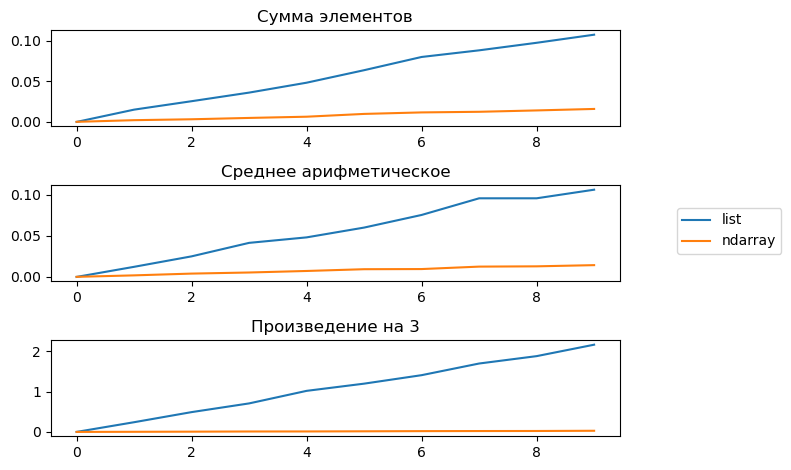

In [9]:
fig, axis = plt.subplots(nrows=3)
for i in range(len(LIST_FUNCTIONS)):
    func_name = LIST_FUNCTIONS[i]

    axis[i].plot(df_list[func_name], label = "list")
    axis[i].plot(df_ndarr[func_name], label = "ndarray")
    axis[i].set_title(func_name)

plt.tight_layout()
plt.legend(loc = [1.1, 1.9])